# 1 — Taxi-out = Decolagem (Takeoff) (OpenSky) − Partida Real (pushback) (VRA/ANAC)


1. Baixa os CSVs mensais do **VRA** (Voo Regular Ativo) da ANAC;
2. Filtra partidas de SBSP e converte **Partida Real** (calços fora, horário de
   Brasília) para UTC;
3. Casa cada voo do VRA com o `firstseen` (≈ decolagem/takeoff) do `flightlist`
4. **Tempo de Taxi (Taxi-out) = Firstseen(takeoff) − Partida Real(pushback)**.

In [1]:
# !pip install pandas 
# !pip install numpy
# !pip instal matplotlib

In [2]:
import unicodedata

import numpy as np
import pandas as pd

def remove_acentos(txt):
    return unicodedata.normalize('NFKD', txt).encode('ascii', 'ignore').decode('utf-8-sig')

VRA_DIR = "data/vra"
FL_DIR = "data/flightlist"
MONTHS = (1, 12)
YEAR = 2025
TZ = "America/Sao_Paulo"


## 1.1 Parse do VRA e filtro de partidas de SBSP

As colunas são localizadas por nome normalizado (sem acento, minúsculas) para
tolerar variações de layout entre meses.

In [3]:
DATAS = ['partida_prevista', 'partida_real', 'chegada_prevista', 'chegada_real']

df = pd.DataFrame()
cgh = pd.DataFrame()
for m in range(MONTHS[0], MONTHS[1] + 1):

    df = pd.read_csv(f"data/vra/VRA_{YEAR}{m}.csv", sep=";", encoding="utf-8-sig",
                     skiprows=1, low_memory=False)
    df.columns = (
        df.columns
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
    )
    df.drop(columns = ['codigo_justificativa', 'codigo_autorizacao_(di)', 'codigo_tipo_linha'], inplace = True)

    # Voos cancelados nao tem pushback (partida_real vazia). Filtrar pela
    # situacao torna o criterio explicito; o dropna cobre so as colunas de que
    # o estudo depende, em vez de exigir a linha inteira preenchida.
    df = df[df['situacao_voo'] == 'REALIZADO']
    df = df.dropna(subset=['icao_empresa_aerea', 'numero_voo', 'partida_real'])

    # [:19] preserva os segundos: o VRA grava "AAAA-MM-DD HH:MM:SS" e um corte
    # em [:18] transformaria 20:04:30 em 20:04:03.
    for col in DATAS:
        df[col] = (
            pd.to_datetime(df[col].str[:19], errors='coerce')
              .dt.tz_localize(TZ)
              .dt.tz_convert('UTC')
        )

    sbsp = df[df['icao_aerodromo_origem'] == 'SBSP']
    cgh = pd.concat([sbsp, cgh], ignore_index=True)

cgh['TEMPO_PREV_VOO'] = cgh['chegada_prevista'] - cgh['partida_prevista']
cgh['TEMPO_REAL_VOO'] = cgh['chegada_real'] - cgh['partida_real']

# A data da chave e a LOCAL, nao a UTC. Um voo que sai dos calcos as 20h50
# (23h50Z) e decola as 21h05 (00h05Z do dia seguinte) tem pushback e decolagem
# em datas UTC diferentes, e a chave nao fecharia. Em data local isso nao
# ocorre: CGH nao opera na virada da meia-noite local.
cgh['index'] = (
    cgh['icao_empresa_aerea'].str.strip().str.upper()
    + cgh['numero_voo'].astype(str).str.strip()
    + '_'
    + cgh['partida_real'].dt.tz_convert(TZ).dt.strftime('%Y-%m-%d')
)
cgh = cgh.set_index('index', drop=True)

print(f"partidas de SBSP no VRA: {len(cgh)}")


partidas de SBSP no VRA: 93370


In [4]:
sbsp_open = pd.DataFrame()
cgh_open = pd.DataFrame()

for m in range(MONTHS[0], MONTHS[1] + 1):
    sbsp_open = pd.read_parquet(f"data/flightlist/fl_{YEAR}{m}.parquet")
    sbsp_open.drop(columns = ['icao24'], inplace = True)
    sbsp_open.rename(columns = {'firstseen':'takeoff', 'lastseen':'landing'}, inplace = True)
    cgh_open = pd.concat([cgh_open, sbsp_open], ignore_index=True)

# A consulta do notebook 0_1 usa airport="SBSP", que devolve partidas E
# chegadas. Numa chegada o firstseen e a decolagem em OUTRO aeroporto, o que
# produziria um taxi-out sem sentido. Manter apenas as partidas.
n_bruto = len(cgh_open)
cgh_open = cgh_open[cgh_open['departure'] == 'SBSP'].drop(columns=['departure'])
print(f"registros do flightlist: {n_bruto} -> {len(cgh_open)} apos manter so partidas de SBSP")

# Chave em data LOCAL, pelo mesmo motivo do lado do VRA.
cgh_open['index'] = (
    cgh_open['callsign'].str.strip().str.upper()
    + '_'
    + cgh_open['takeoff'].dt.tz_convert(TZ).dt.strftime('%Y-%m-%d')
)


registros do flightlist: 169275 -> 89793 apos manter so partidas de SBSP


In [5]:
pares = cgh.merge(
    cgh_open,
    how="inner",
    left_index=True,
    right_on="index",
)
pares = pares.rename(columns = {'takeoff':'decolagem'})
pares = pares[['index', 'callsign', 'day', 'partida_real', 'decolagem',
               'partida_prevista']].drop_duplicates()
pares['taxi_out_min'] = (pares['decolagem'] - pares['partida_real']).dt.total_seconds() / 60

# A chave nao e unica dos dois lados: o mesmo numero de voo pode operar duas
# vezes na mesma data. Nesse caso o merge inner faz o PRODUTO CARTESIANO e
# cria emparelhamentos falsos (o pushback das 23h com a decolagem das 00h09 do
# outro voo, por exemplo), que e a origem dos taxi-out proximos de +-1440 min.
# Regra de desempate: para cada voo do VRA, a PRIMEIRA decolagem igual ou
# posterior ao pushback. Decolagem anterior ao pushback e impossivel.
n_pares = len(pares)
n_chaves = pares['index'].nunique()

merged = (
    pares[pares['taxi_out_min'] >= 0]
    .sort_values('taxi_out_min')
    .groupby('index', as_index=False)
    .first()
    .set_index('index')
)
merged['taxi_out'] = merged['decolagem'] - merged['partida_real']
merged = merged[['callsign', 'day', 'partida_real', 'decolagem',
                 'partida_prevista', 'taxi_out', 'taxi_out_min']]

print(f"combinacoes gerada pelo merge:      {n_pares}")
print(f"voos distintos do VRA nessas chaves: {n_chaves}")
print(f"emparelhamentos falsos descartados:  {n_pares - n_chaves}")
print(f"voos apos o desempate:               {len(merged)}"
      f"  ({n_chaves - len(merged)} sem nenhuma decolagem posterior ao pushback)")


combinacoes gerada pelo merge:      75092
voos distintos do VRA nessas chaves: 75064
emparelhamentos falsos descartados:  28
voos apos o desempate:               75055  (9 sem nenhuma decolagem posterior ao pushback)


In [6]:
merged.info()

<class 'pandas.DataFrame'>
Index: 75055 entries, AZU2200_2025-12-13 to TAM9320_2025-09-13
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype                        
---  ------            --------------  -----                        
 0   callsign          75055 non-null  string                       
 1   day               75055 non-null  timestamp[s, tz=UTC][pyarrow]
 2   partida_real      75055 non-null  datetime64[us, UTC]          
 3   decolagem         75055 non-null  timestamp[s, tz=UTC][pyarrow]
 4   partida_prevista  75055 non-null  datetime64[us, UTC]          
 5   taxi_out          75055 non-null  duration[us][pyarrow]        
 6   taxi_out_min      75055 non-null  double[pyarrow]              
dtypes: datetime64[us, UTC](2), double[pyarrow](1), duration[us][pyarrow](1), string(1), timestamp[s, tz=UTC][pyarrow](2)
memory usage: 6.4 MB


In [7]:
merged.to_parquet("data/processed/cgh_taxi_out_2025.parquet")

## 1.2 Diagnóstico do dataset

O parquet acima é o dataset **bruto**: todo par casado, sem nenhum corte. As
quatro seções a seguir documentam sua qualidade antes da limpeza e da criação
de features (notebook `05_prep_features`) — são a evidência de que a variável
dependente, construída a partir de duas fontes independentes, é confiável.

Os gráficos usam **matplotlib** em vez de plotly porque o GitHub renderiza
imagens estáticas embutidas no notebook, mas não figuras interativas.


### 1.2.1 O produto cartesiano do join e por que ele precisa ser desfeito

A chave do join — `(empresa + número do voo + data local)` de um lado,
`(callsign + data local)` do outro — **não é única**. Duas situações a quebram:

1. **A perna de entrada.** O mesmo callsign que parte de Congonhas costuma ter
   decolado de outro aeroporto no mesmo dia, para chegar ali. Se o registro
   dessa chegada entra na base, sua decolagem — que ocorreu em outro aeroporto
   e em outro horário — compete pela mesma chave. Foi a causa dominante, e é
   por isso que a filtragem por `departure == 'SBSP'` na célula anterior é
   essencial.
2. **Voo repetido no dia.** O mesmo número de voo pode operar duas vezes na
   mesma data, gerando dois candidatos legítimos.

Em ambos os casos o `merge` inner devolve todas as combinações possíveis, e as
erradas produzem taxi-out sem sentido físico — o pushback das 23h emparelhado
com uma decolagem das 00h09 gera valores próximos de **±1440 min**. A regra de
desempate (primeira decolagem igual ou posterior ao pushback) resolve o
problema na origem: as contagens abaixo do gráfico mostram quantas combinações
o merge gerou e quantas sobreviveram.

O histograma traz a distribuição resultante, com o corte de sanidade de 3 a 90
min em vermelho. As linhas praticamente não cortam nada — sinal de que os
valores extremos eram defeito de emparelhamento, não comportamento do taxi-out.


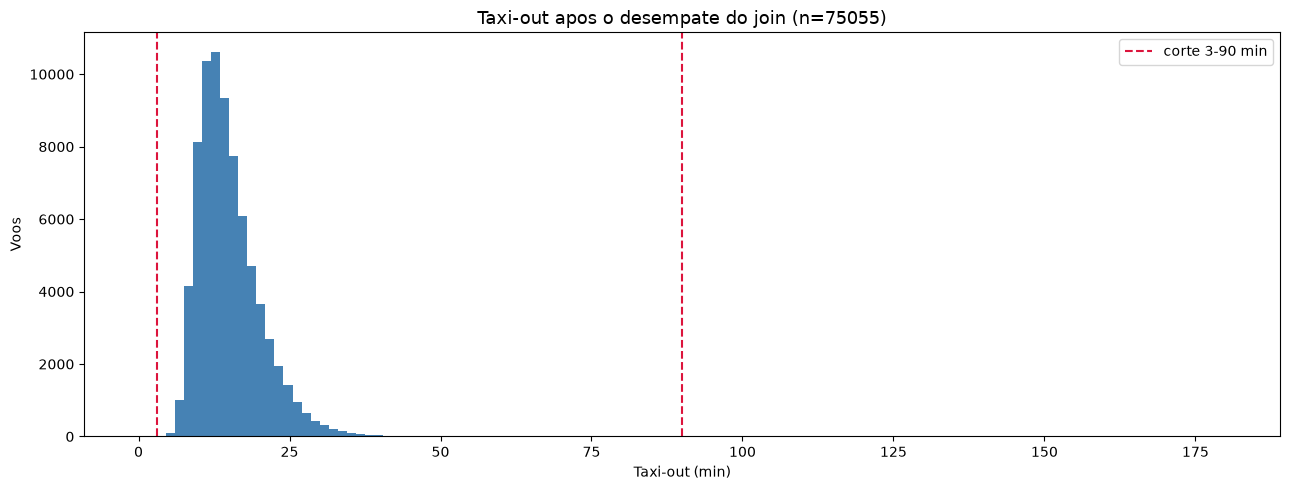

combinacoes geradas pelo merge:      75092
  com |taxi| > 1000 min:                 2
  com taxi negativo:                    24
--------------------------------------------
voos apos o desempate:               75055
  fora da faixa 3-90 min:              36
  mediana dentro da faixa:            13.9 min


In [8]:
import matplotlib.pyplot as plt

LIM_INF, LIM_SUP = 3, 90  # corte de sanidade, aplicado no notebook de features

# O parquet devolve dtypes com backend Arrow (double[pyarrow]); o matplotlib
# precisa de float64 do numpy.
antes = pares["taxi_out_min"].to_numpy(dtype="float64", na_value=np.nan)
bruto = merged["taxi_out_min"].to_numpy(dtype="float64", na_value=np.nan)

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(bruto, bins=120, range=(0, 180), color="steelblue")
ax.axvline(LIM_INF, color="crimson", ls="--", lw=1.5, label=f"corte {LIM_INF}-{LIM_SUP} min")
ax.axvline(LIM_SUP, color="crimson", ls="--", lw=1.5)
ax.set_title(f"Taxi-out apos o desempate do join (n={len(bruto)})", fontsize=13)
ax.set_xlabel("Taxi-out (min)")
ax.set_ylabel("Voos")
ax.legend()

plt.tight_layout()
plt.show()

print(f"combinacoes geradas pelo merge:     {len(antes):>6}")
print(f"  com |taxi| > 1000 min:            {int((np.abs(antes) > 1000).sum()):>6}")
print(f"  com taxi negativo:                {int((antes < 0).sum()):>6}")
print("-" * 44)
print(f"voos apos o desempate:              {len(bruto):>6}")
print(f"  fora da faixa {LIM_INF}-{LIM_SUP} min:          "
      f"{int(((bruto < LIM_INF) | (bruto > LIM_SUP)).sum()):>6}")
print(f"  mediana dentro da faixa:          "
      f"{np.median(bruto[(bruto >= LIM_INF) & (bruto <= LIM_SUP)]):>6.1f} min")


### 1.2.2 Funil de casamento: quantos voos sobrevivem a cada etapa

A taxa de casamento é a primeira pergunta sobre um dataset montado por join. As
duas fontes **não cobrem o mesmo universo**: o `flightlist` da OpenSky traz
qualquer partida detectada em SBSP (inclusive aviação geral e voos atribuídos ao
aeroporto errado pela segmentação da rede), enquanto o VRA cobre apenas a
aviação comercial regular. O casamento é justamente o que restringe o estudo ao
universo do VRA — por isso a taxa é calculada **sobre o VRA**, não sobre o
`flightlist`.

A tabela por companhia serve para checar se a perda é aproximadamente uniforme.
Perda concentrada em uma empresa seria viés de seleção e precisaria ser
declarada como limitação.


In [9]:
n_vra = len(cgh)
n_fl = len(cgh_open)
n_par = len(merged)
n_limpo = int(((bruto >= LIM_INF) & (bruto <= LIM_SUP)).sum())

funil = pd.DataFrame(
    {
        "etapa": [
            "Partidas de SBSP no VRA (ANAC)",
            "Partidas de SBSP no flightlist (OpenSky)",
            "Voos casados (callsign x data local)",
            f"Apos o corte de sanidade ({LIM_INF} a {LIM_SUP} min)",
        ],
        "n": [n_vra, n_fl, n_par, n_limpo],
        "% do VRA": [100.0, np.nan, n_par / n_vra * 100, n_limpo / n_vra * 100],
    }
)
funil["% do VRA"] = funil["% do VRA"].round(1)
display(funil)

print(f"Taxa de casamento: {n_par / n_vra * 100:.1f}% dos voos do VRA")
print(f"Aproveitamento final: {n_limpo / n_vra * 100:.1f}% dos voos do VRA\n")

# A perda esta concentrada em alguma companhia?
por_cia = (
    cgh.assign(casado=cgh.index.isin(set(merged.index)))
    .groupby("icao_empresa_aerea")["casado"]
    .agg(voos_vra="size", casados="sum")
)
por_cia["taxa_%"] = (por_cia["casados"] / por_cia["voos_vra"] * 100).round(1)
display(por_cia.sort_values("voos_vra", ascending=False))


,etapa,n,% do VRA
0,Partidas de SBSP no VRA (ANAC),93370,100.0
1,Partidas de SBSP no flightlist (OpenSky),89793,NaN
2,Voos casados (callsign x data local),75055,80.4
3,Apos o corte de sanidade (3 a 90 min),75019,80.3


Taxa de casamento: 80.4% dos voos do VRA
Aproveitamento final: 80.3% dos voos do VRA



,voos_vra,casados,taxa_%
icao_empresa_aerea,,,
TAM,40218,34627,86.1
GLO,38800,31686,81.7
AZU,13705,8685,63.4
PTB,645,57,8.8
ACN,2,0,0.0


### 1.2.3 Cobertura ao longo do ano

Esta figura testa a decisão de desenho do estudo. O pipeline alternativo, que
derivava o taxi-out apenas de *state vectors* ADS-B, só funcionava de **ago a
dez/2025**: antes disso não havia receptor com visada da superfície de CGH. O
desenho adotado — `firstseen` do `flightlist` menos a Partida Real do VRA — foi
escolhido por **não** depender de cobertura de solo, e a expectativa era uma
taxa de casamento estável nos doze meses.

O gráfico mostra que essa expectativa **só se confirma em parte** — ver a
leitura na seção 1.2.4.


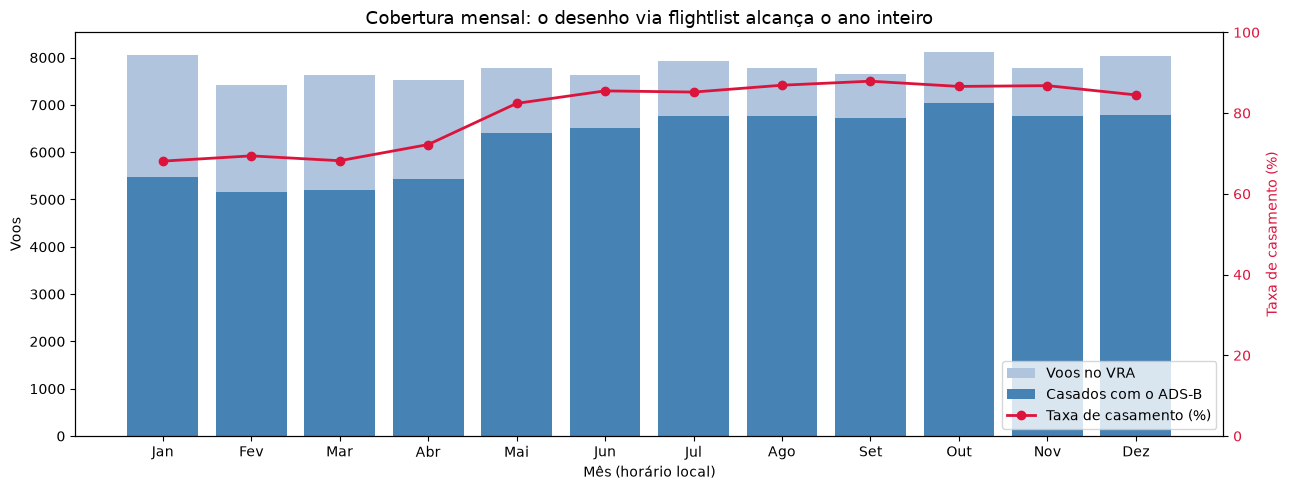

,vra,casados,taxa_%
Jan,8050,5486,68.1
Fev,7430,5155,69.4
Mar,7640,5211,68.2
Abr,7529,5438,72.2
Mai,7775,6403,82.4
Jun,7626,6519,85.5
Jul,7935,6764,85.2
Ago,7784,6768,86.9
Set,7655,6726,87.9
Out,8127,7041,86.6


In [10]:
TZ = "America/Sao_Paulo"

mes_vra = cgh["partida_real"].dt.tz_convert(TZ).dt.month.value_counts().sort_index()
mes_par = merged["partida_real"].dt.tz_convert(TZ).dt.month.value_counts().sort_index()

cobertura = pd.DataFrame({"vra": mes_vra, "casados": mes_par}).reindex(range(1, 13)).fillna(0)
cobertura["taxa_%"] = (cobertura["casados"] / cobertura["vra"] * 100).round(1)

MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(MESES, cobertura["vra"], color="lightsteelblue", label="Voos no VRA")
ax1.bar(MESES, cobertura["casados"], color="steelblue", label="Casados com o ADS-B")
ax1.set_ylabel("Voos")
ax1.set_xlabel("Mês (horário local)")

ax2 = ax1.twinx()
ax2.plot(MESES, cobertura["taxa_%"], color="crimson", marker="o", lw=2,
         label="Taxa de casamento (%)")
ax2.set_ylabel("Taxa de casamento (%)", color="crimson")
ax2.set_ylim(0, 100)
ax2.tick_params(axis="y", labelcolor="crimson")

linhas = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
rotulos = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(linhas, rotulos, loc="lower right")

plt.title("Cobertura mensal: o desenho via flightlist alcança o ano inteiro", fontsize=13)
plt.tight_layout()
plt.show()

display(cobertura.set_axis(MESES))


### 1.2.4 Leitura dos diagnósticos

**O dataset final tem 75.055 voos, com mediana de 13,9 min.** Depois de manter
apenas partidas de SBSP no lado da OpenSky e de desfazer o produto cartesiano,
restam **2** combinações com |taxi| > 1000 min e **36** voos fora da faixa de 3
a 90 min.

**A taxa de casamento é de 80,4%** dos 93.370 voos do VRA — mas ela **não é
uniforme**, e isso é uma limitação do estudo:

- **Por companhia:** TAM 86,1% e GLO 81,7%, contra **AZU 63,4%** e PTB 8,8%
  (645 voos no ano). A amostra final pende para LATAM e GOL.
- **Por mês:** cerca de **68% de jan a abr** contra **87–88% de set a nov**. O
  degrau ocorre em maio, quando a cobertura da OpenSky em SBSP melhorou.

**Consequência para a modelagem.** O efeito de `mes` é a variável de maior
importância, e parte dele pode ser **composição da amostra**, não comportamento
do taxi-out: os meses do início do ano são representados por um subconjunto
menor e com mix de companhias diferente. O **total de partidas no VRA é
praticamente constante** ao longo de 2025 (7.430 a 8.127 voos/mês, sem
tendência) — o crescimento na série de voos casados é de **cobertura**, não de
tráfego.
